In [53]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [54]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np

In [55]:
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

In [56]:
X_train = X_train/255.0
X_test = X_test/255.0

In [57]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


9


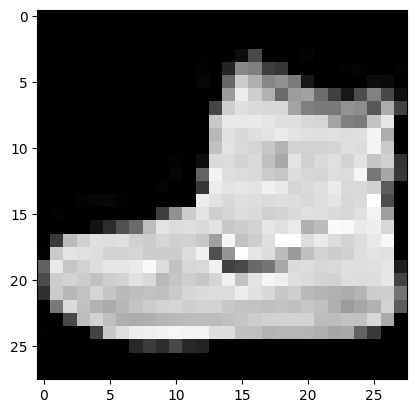

In [58]:
plt.imshow(X_train[0], cmap='gray')
plt.show
print(y_train[0])

In [59]:
model = keras.Sequential([
    layers.Input(shape=(28,28)),
    layers.Flatten(),
    layers.Dense(128, activation = 'relu'),
    layers.Dense(64, activation = 'relu'),
    layers.Dense(10, activation = 'softmax')
])

In [60]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [61]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    validation_split=0.2
)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7680 - loss: 0.6688 - val_accuracy: 0.8462 - val_loss: 0.4270
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8559 - loss: 0.3943 - val_accuracy: 0.8487 - val_loss: 0.4051
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8695 - loss: 0.3469 - val_accuracy: 0.8690 - val_loss: 0.3699
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8860 - loss: 0.3105 - val_accuracy: 0.8777 - val_loss: 0.3441
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8924 - loss: 0.2957 - val_accuracy: 0.8751 - val_loss: 0.3483


In [62]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print("test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8690 - loss: 0.3663
test Accuracy: 0.866100013256073


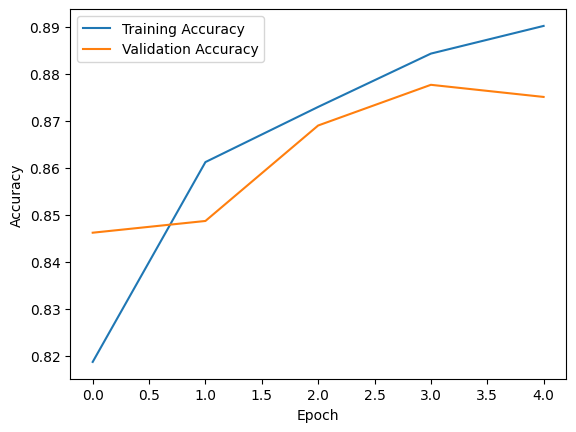

In [63]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [64]:
print(X_train.min())
print(X_train.max())
print(X_train.dtype)

0.0
1.0
float64


In [48]:
print(np.unique(y_train))
print(len(np.unique(y_train)))

[0.         0.00392157 0.00784314 0.01176471 0.01568627 0.01960784
 0.02352941 0.02745098 0.03137255 0.03529412]
10


In [50]:
print(tf.__version__)

2.19.0


In [51]:
print(np.unique(y_train))

[0.         0.00392157 0.00784314 0.01176471 0.01568627 0.01960784
 0.02352941 0.02745098 0.03137255 0.03529412]


In [65]:
class_names = [
    'T-shirt/top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle boot'
]

In [66]:
predictions = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


<function matplotlib.pyplot.show(close=None, block=None)>

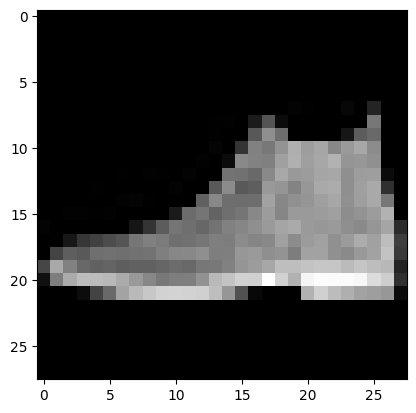

In [67]:
index = 0
plt.imshow(X_test[index], cmap='gray')
plt.show

In [68]:
print("predicted:", class_names[np.argmax(predictions[index])])
print("actual:", class_names[y_test[index]])

predicted: Ankle boot
actual: Ankle boot


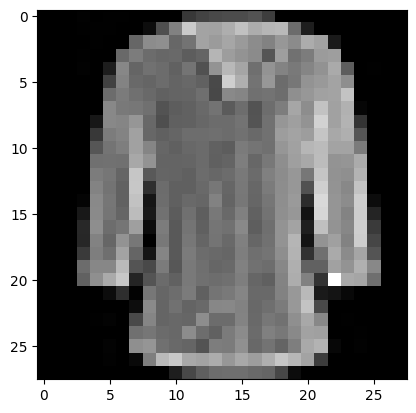

In [75]:
for i in range(5):
    plt.imshow(X_test[i], cmap='gray')
    plt.show
    predicted = class_names[np.argmax(predictions[i])]
    actual = class_names[y_test[i]]

In [74]:
print("prediction:",predicted)
print("actual:", actual)

prediction: Shirt
actual: Shirt
